In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fileName = r"C:\Users\user\Downloads\LA_AQS_2023.csv"
pd.read_csv(fileName)

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
0,6,37,1103,68103,1,34.06659,-118.22688,WGS84,Ambient Min Temperature,24 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
2,6,37,1103,62201,1,34.06659,-118.22688,WGS84,Relative Humidity,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
3,6,37,1103,62101,1,34.06659,-118.22688,WGS84,Outdoor Temperature,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
4,6,37,1103,42603,1,34.06659,-118.22688,WGS84,Oxides of nitrogen (NOx),1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22155,6,37,1103,63301,1,34.06659,-118.22688,WGS84,Solar radiation,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
22156,6,37,1103,61104,1,34.06659,-118.22688,WGS84,Wind Direction - Resultant,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
22157,6,37,1103,61103,1,34.06659,-118.22688,WGS84,Wind Speed - Resultant,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
22158,6,37,1103,62201,1,34.06659,-118.22688,WGS84,Relative Humidity,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [3]:
df = pd.read_csv(fileName)

In [4]:
df.columns = df.columns.str.strip()

In [5]:
df["Arithmetic Mean"] = pd.to_numeric(df["Arithmetic Mean"])

In [6]:
df["Date (Local)"] = pd.to_datetime(df["Date (Local)"])

In [7]:
df.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
0,6,37,1103,68103,1,34.06659,-118.22688,WGS84,Ambient Min Temperature,24 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
2,6,37,1103,62201,1,34.06659,-118.22688,WGS84,Relative Humidity,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
3,6,37,1103,62101,1,34.06659,-118.22688,WGS84,Outdoor Temperature,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
4,6,37,1103,42603,1,34.06659,-118.22688,WGS84,Oxides of nitrogen (NOx),1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [8]:
o3 = df[df["Parameter Name"].str.contains("Ozone", case=False, na=False)].copy()

In [9]:
no2 = df[df["Parameter Name"].str.contains("Nitrogen dioxide",case=False,na=False)].copy()

In [10]:
o3["O3_ppb"] = o3["Arithmetic Mean"] * 1000

In [11]:
no2["NO2_ppb"] = no2["Arithmetic Mean"]

In [12]:
print(o3["Units of Measure"].unique())
print(no2["Units of Measure"].unique())

<ArrowStringArray>
['Parts per million']
Length: 1, dtype: str
<ArrowStringArray>
['Parts per billion']
Length: 1, dtype: str


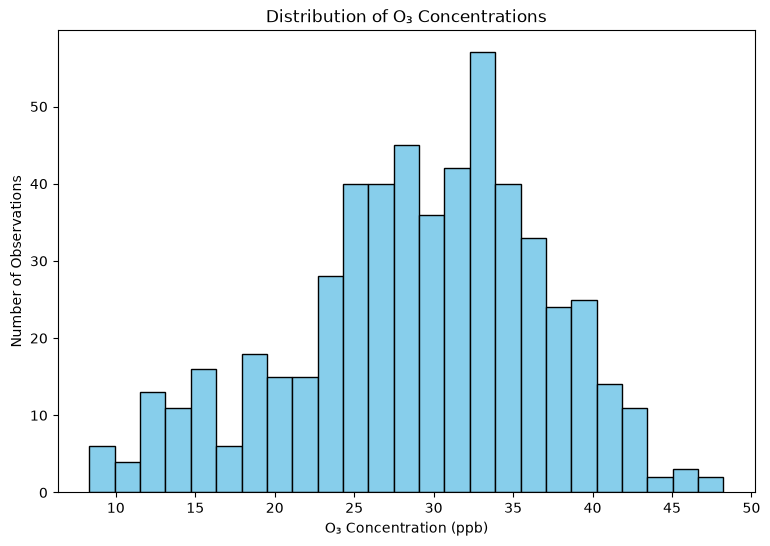

In [13]:
plt.figure(figsize=(9,6))

plt.hist(o3["O3_ppb"].dropna(),bins=25,color="skyblue",edgecolor="black")

plt.xlabel("O₃ Concentration (ppb)")
plt.ylabel("Number of Observations")
plt.title("Distribution of O₃ Concentrations")
plt.show()

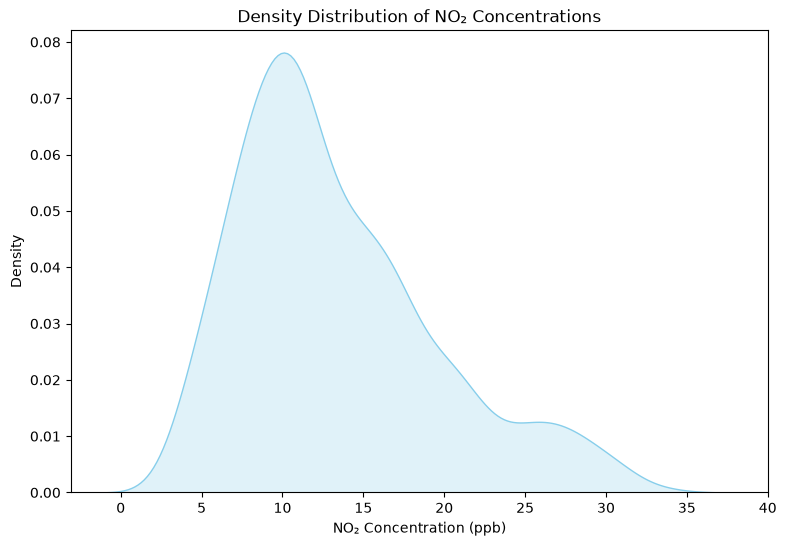

In [14]:
plt.figure(figsize=(9,6))

sns.kdeplot(data=no2,x="NO2_ppb",fill=True,color="skyblue")

plt.xlabel("NO₂ Concentration (ppb)")
plt.ylabel("Density")
plt.title("Density Distribution of NO₂ Concentrations")
plt.show()

In [15]:
o3_ppb = o3["O3_ppb"]
date1_o3 = o3["Date (Local)"]

no2_ppb = no2["NO2_ppb"]
date2_no2 = no2["Date (Local)"]

In [16]:
df_1 = pd.DataFrame(data={"O3_ppb": o3_ppb, "date": date1_o3})
df_2 = pd.DataFrame(data={"NO2_ppb": no2_ppb, "date": date2_no2})
df_all = df_1.merge(df_2, on=["date"])

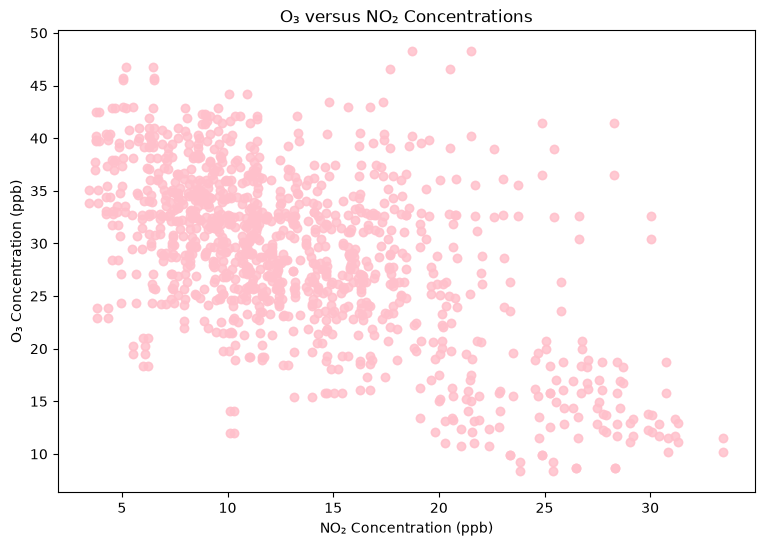

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df_all["NO2_ppb"],df_all["O3_ppb"],color="pink",alpha=0.6)

plt.xlabel("NO₂ Concentration (ppb)")
plt.ylabel("O₃ Concentration (ppb)")
plt.title("O₃ versus NO₂ Concentrations")
plt.show()

In [18]:
daily_o3 = (o3.groupby("Date (Local)", as_index=False)["O3_ppb"].mean())

In [19]:
high_o3 = daily_o3[daily_o3["O3_ppb"] > 35].copy()

high_o3["Month"] = high_o3["Date (Local)"].dt.month

In [20]:
days_per_month = (high_o3.groupby("Month").size().reindex(range(1, 13), fill_value=0))

month_names = ["Jan", "Feb", "Mar", "Apr","May", "Jun", "Jul", "Aug","Sep", "Oct", "Nov", "Dec"]

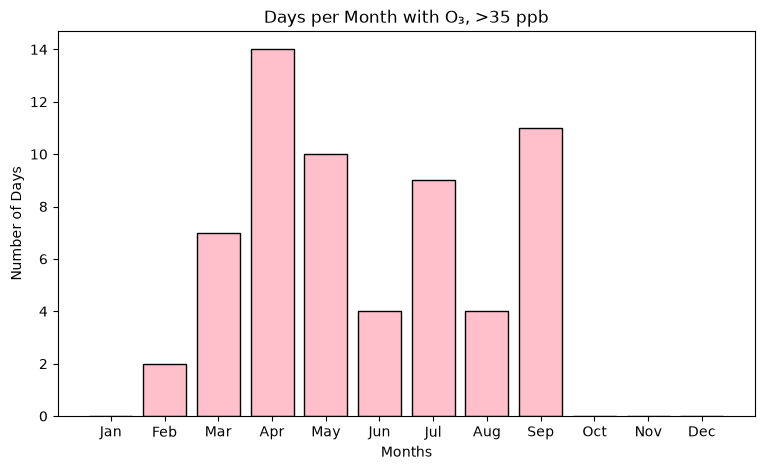

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(month_names,days_per_month.values,color="pink",edgecolor="black")

ax.set_xlabel("Months")
ax.set_ylabel("Number of Days")
ax.set_title("Days per Month with O₃, >35 ppb")
plt.show()

In [22]:
fileName = r"C:\Users\user\Downloads\ManuaLoa_CO2.csv"
pd.read_csv(fileName)

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
786,2023,9,2023.7083,418.51,421.96,18,0.30,0.14
787,2023,10,2023.7917,418.82,422.12,27,0.47,0.17
788,2023,11,2023.8750,420.46,422.43,21,0.91,0.38
789,2023,12,2023.9583,421.86,422.56,20,0.70,0.30


In [23]:
co2 = pd.read_csv(fileName)

In [24]:
co2.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99


In [25]:
print(co2.columns.tolist())

['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays', 'sdev', 'unc']


In [26]:
co2.columns = (co2.columns.str.strip().str.lower().str.replace(" ", "_"))

In [27]:
co2["decimal_date"] = pd.to_numeric(co2["decimal_date"])

co2["average"] = pd.to_numeric(co2["average"])

co2_clean = co2.dropna(subset=["decimal_date", "average"])

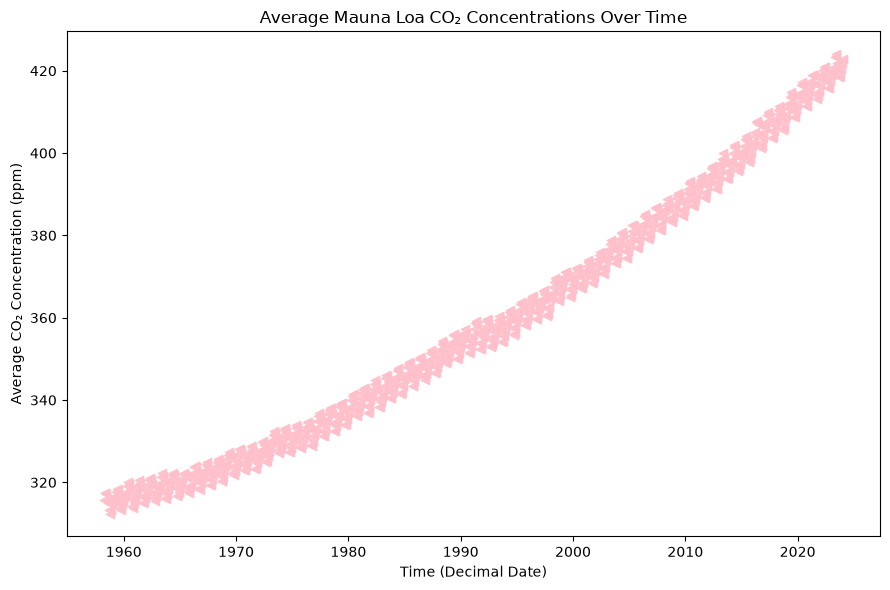

In [28]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(co2_clean["decimal_date"],co2_clean["average"],color="pink",marker ="<",alpha=0.9)

ax.set_xlabel("Time (Decimal Date)")
ax.set_ylabel("Average CO₂ Concentration (ppm)")
ax.set_title("Average Mauna Loa CO₂ Concentrations Over Time")

plt.tight_layout()
plt.show()

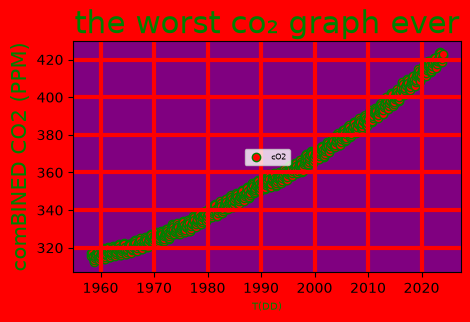

In [29]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(co2_clean["decimal_date"],co2_clean["average"],color="red",edgecolor="green",label="cO2")
ax.set_facecolor("purple")
fig.patch.set_facecolor("red")

ax.set_xlabel("T(DD)",color="green",fontsize=7)

ax.set_ylabel("comBINED CO2 (PPM)",color="green",fontsize=15)

ax.set_title("the worst co₂ graph ever",color="green",fontsize=22)

ax.grid(True,color="red",linewidth=3)

ax.legend(fontsize=6,loc="center")

plt.show()